# Decision and Regression Trees

A **decision tree** classifies by asking a series of yes/no questions about the features like "is glucose less than 120? go left, else go right," over and over until it reaches a leaf, which gives the answer. Geometrically it chops the feature space into rectangular blocks with lines that are always straight and axis-aligned, a very different shape from the curves and bumpy regions of the earlier models.

The same idea does **regression**: instead of a class, each leaf predicts the *average* value of the training points that land in it, so the prediction comes out as a flat staircase.

The big appeal of trees is that they are **easy to read**. Unlike a neural network, you can look at a trained tree and see exactly which features and cutoffs led to each prediction. The catch is that they **overfit easily**: let the tree grow deep enough and it just memorizes the training data.

This notebook builds both kinds with scikit-learn: a decision tree to predict diabetes, and a regression tree to predict medical charges.

## A Classification Tree: Predicting Diabetes

I use the Pima diabetes dataset, which has 768 patients with measurements like glucose, blood pressure, and BMI, and a label for whether they developed diabetes. I'll classify on two features, **glucose** and **BMI**, so I can draw the decision regions.

### The Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error
import os

sns.set_theme()
PURPLE, GREEN = "#5d32ca", "#82b600"

_local_diabetes = os.path.join(os.getcwd(), "..", "Datasets", "Diabetes Dataset for Decision Trees.csv")
try:
    df = pd.read_csv(_local_diabetes)
    print("loaded diabetes data from local Datasets folder")
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv")
    print("loaded diabetes data from URL (local file not found)")

# Some of the rows have 0 for glucose or BMI, which really means "missing", so drop them.
df = df[(df["Glucose"] > 0) & (df["BMI"] > 0)]
X = df[["Glucose", "BMI"]].to_numpy()
y = df["Outcome"].to_numpy()              # 1 = diabetes, 0 = no diabetes
print("patients:", len(y), "| diabetes:", y.sum(), "| no diabetes:", (y == 0).sum())

loaded diabetes data from local Datasets folder
patients: 752 | diabetes: 264 | no diabetes: 488


Here are the two features colored by the diagnosis. Higher glucose clearly leans toward diabetes, but the two groups overlap a lot, so this won't be a clean split.

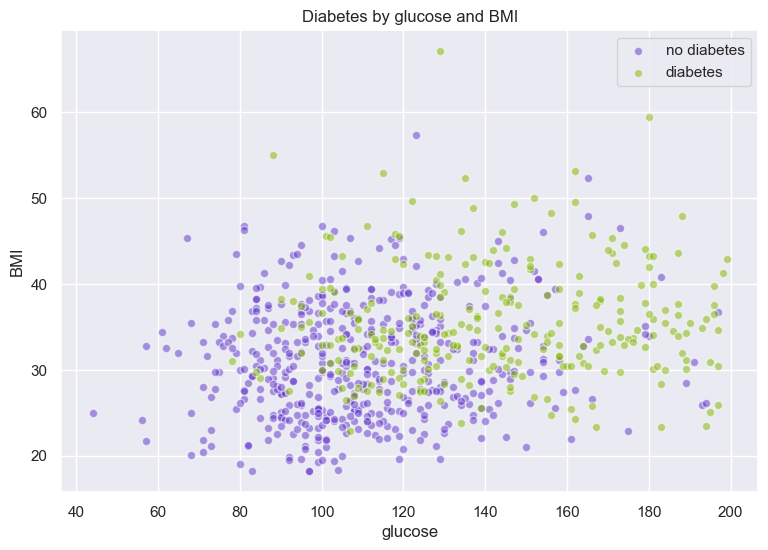

In [18]:
plt.figure(figsize=(9, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color=PURPLE, alpha=0.5, edgecolors="white", label="no diabetes")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color=GREEN, alpha=0.5, edgecolors="white", label="diabetes")
plt.xlabel("glucose")
plt.ylabel("BMI")
plt.title("Diabetes by glucose and BMI")
plt.legend()
plt.show()

One nice thing about trees: they split one feature at a time, so the scale of each feature doesn't matter. There's **no need to standardize** here, unlike KNN. I just split into train and test.

### Building the Tree

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("train:", len(y_train), "| test:", len(y_test))

train: 564 | test: 188


Now I build the tree with `DecisionTreeClassifier` and a `max_depth` of 4 to keep it readable. The best part is that I can **draw the whole thing** and read it top to bottom: each box shows the split rule, the Gini score (0 = pure, all one class), and how many samples fall there.

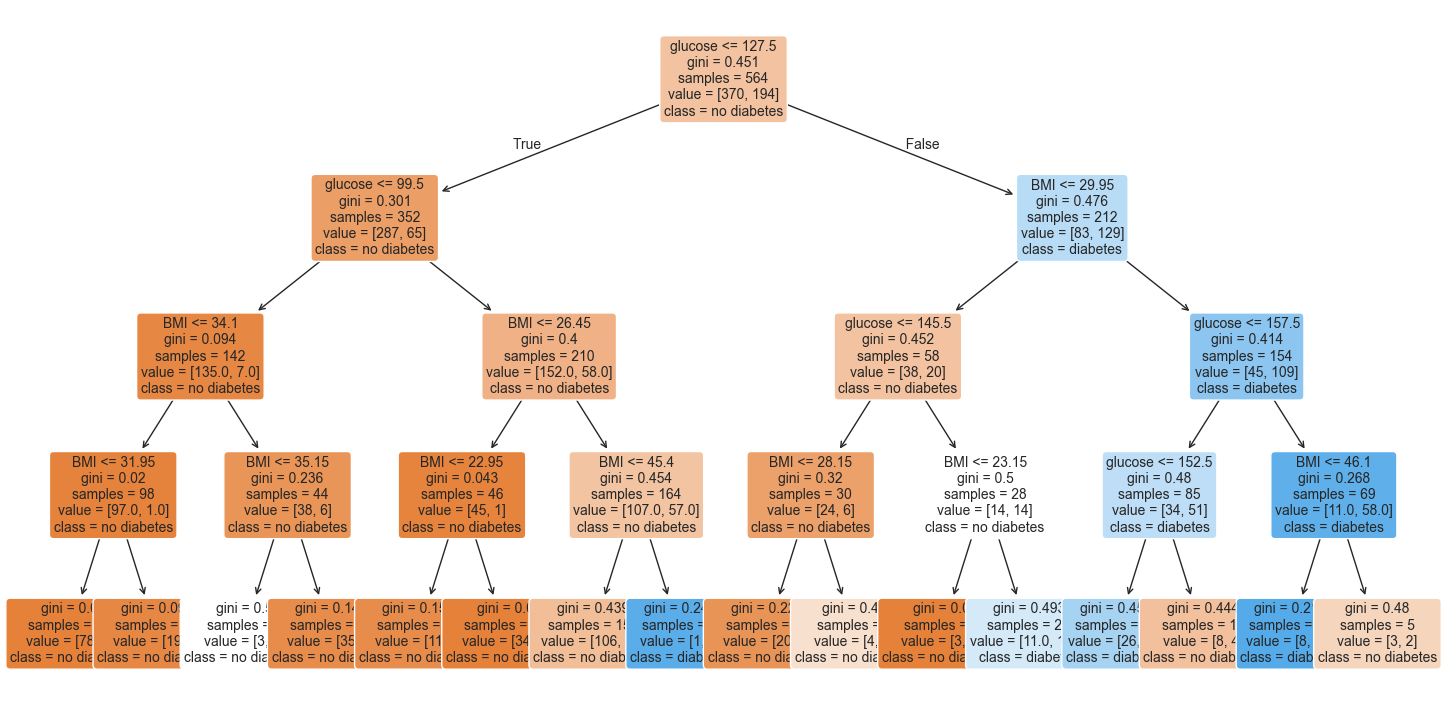

In [20]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

plt.figure(figsize=(18, 9))
plot_tree(tree, feature_names=["glucose", "BMI"], class_names=["no diabetes", "diabetes"],
          filled=True, rounded=True, fontsize=10)
plt.show()

### Decision Regions

Here are the decision regions with the **training data** plotted on top, these are the points the tree actually learned from. Notice the regions are made of **rectangular blocks** with straight, axis-aligned edges, because every split is just "is this one feature above or below a cutoff."

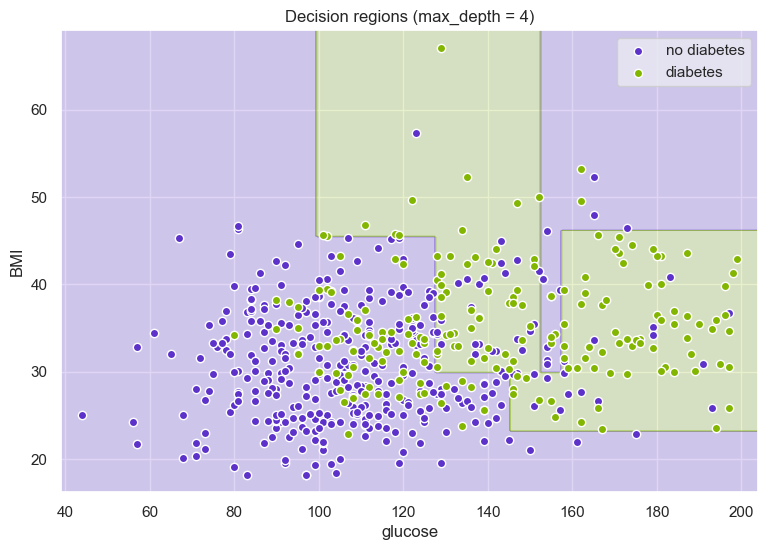

In [21]:
def plot_regions(model, depth_note=""):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-5, X[:, 0].max()+5, 300),
                         np.linspace(X[:, 1].min()-2, X[:, 1].max()+2, 300))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, zz, alpha=0.2, cmap=ListedColormap([PURPLE, GREEN]))
    plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color=PURPLE, edgecolors="white", label="no diabetes")
    plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color=GREEN, edgecolors="white", label="diabetes")
    plt.xlabel("glucose"); plt.ylabel("BMI"); plt.title(f"Decision regions {depth_note}")
    plt.legend(); plt.show()

plot_regions(tree, "(max_depth = 4)")

Now the same decision regions with the **test data**, points the tree has never seen. These are the patients used to evaluate how well the tree generalizes.

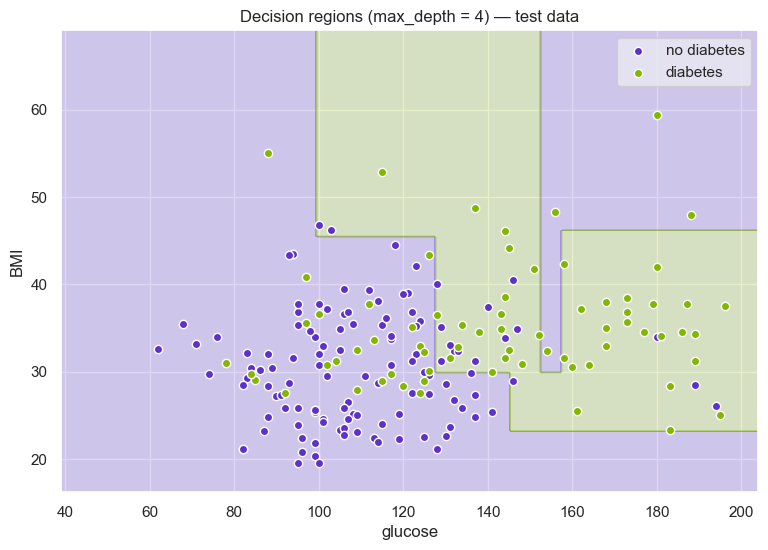

In [22]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-5, X[:, 0].max()+5, 300),
                     np.linspace(X[:, 1].min()-2, X[:, 1].max()+2, 300))
zz = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, zz, alpha=0.2, cmap=ListedColormap([PURPLE, GREEN]))
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color=PURPLE, edgecolors="white", label="no diabetes")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color=GREEN, edgecolors="white", label="diabetes")
plt.xlabel("glucose"); plt.ylabel("BMI"); plt.title("Decision regions (max_depth = 4) — test data")
plt.legend(); plt.show()

As you'll notice, the test data doesn't always sit where you'd expect given the regions the tree carved out. Look at the **top-right region**: the training data had a cluster of purple (no diabetes) points there, so the tree drew a purple region, but in the test set, no purple points show up. The tree made a boundary based on what it saw, and the test data simply isn't distributed the same way. That mismatch is normal with a 25% test split and a finite dataset, and it's a good reminder that the regions reflect the training data's layout, not some all the data possible.

### Model Evaluation

To check how it does, I look at the accuracy, the confusion matrix, and the classification report.

- **Precision** — of all the patients the tree *predicted* as diabetic, what fraction actually were? High precision means few false alarms.
- **Recall** — of all the patients who *actually* had diabetes, what fraction did the tree catch? High recall means few missed cases.

Both matter here, but missing a real diabetes case (low recall) is generally worse than a false alarm (low precision), so recall deserves extra attention.

Test accuracy: 76.1%



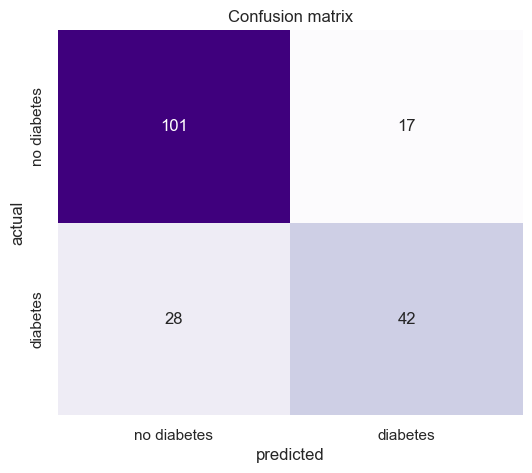

              precision    recall  f1-score   support

 no diabetes       0.78      0.86      0.82       118
    diabetes       0.71      0.60      0.65        70

    accuracy                           0.76       188
   macro avg       0.75      0.73      0.73       188
weighted avg       0.76      0.76      0.76       188



In [24]:
y_pred = tree.predict(X_test)
print(f"Test accuracy: {(y_pred == y_test).mean():.1%}\n")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["no diabetes", "diabetes"], yticklabels=["no diabetes", "diabetes"])
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Confusion matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=["no diabetes", "diabetes"]))

### Overfitting

Trees can overfit, If I let the depth grow, the regions break into tiny islands that chase individual points, the model memorizing the training noise instead of the real pattern. Here's a depth-15 tree on the same data:

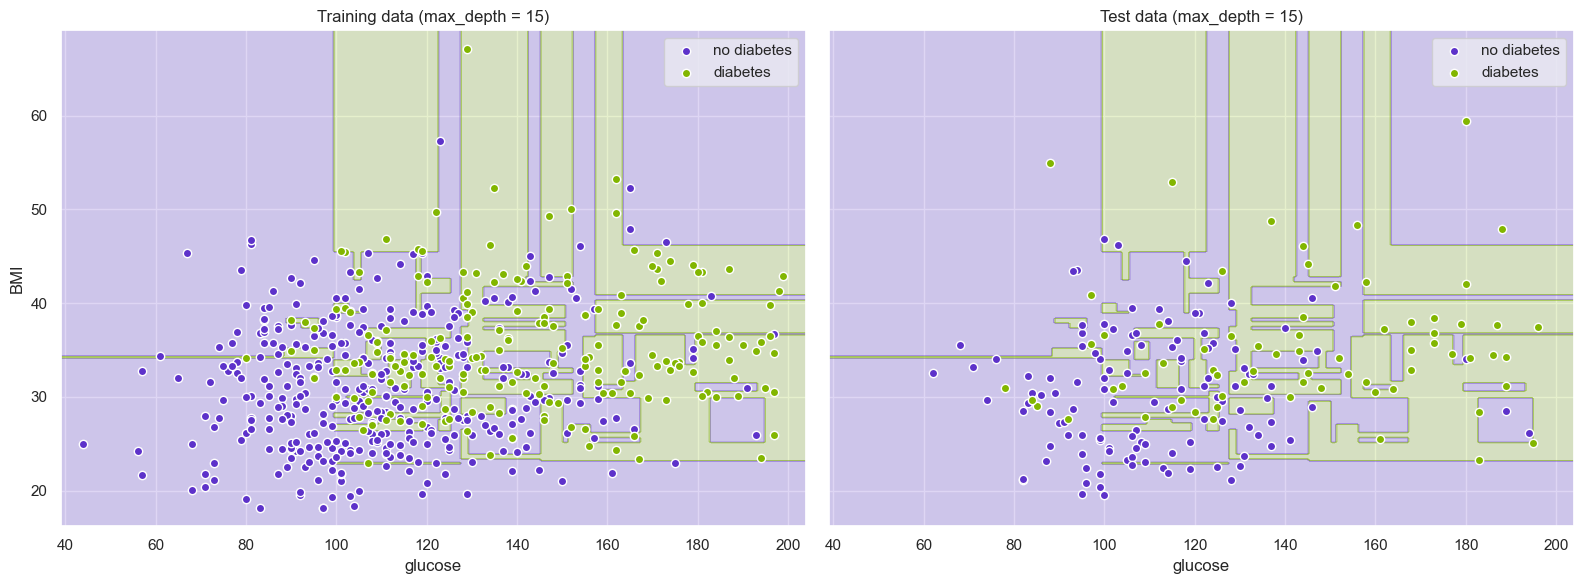

In [48]:
deep_tree = DecisionTreeClassifier(max_depth=15, random_state=42)
deep_tree.fit(X_train, y_train)

xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-5, X[:, 0].max()+5, 300),
                     np.linspace(X[:, 1].min()-2, X[:, 1].max()+2, 300))
zz = deep_tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, title, Xp, yp in [
    (ax1, "Training data (max_depth = 15)", X_train, y_train),
    (ax2, "Test data (max_depth = 15)",     X_test,  y_test),
]:
    ax.contourf(xx, yy, zz, alpha=0.2, cmap=ListedColormap([PURPLE, GREEN]))
    ax.scatter(Xp[yp == 0, 0], Xp[yp == 0, 1], color=PURPLE, edgecolors="white", label="no diabetes")
    ax.scatter(Xp[yp == 1, 0], Xp[yp == 1, 1], color=GREEN,  edgecolors="white", label="diabetes")
    ax.set_xlabel("glucose"); ax.set_title(title); ax.legend()

ax1.set_ylabel("BMI")
plt.tight_layout()
plt.show()

The same regions, but two different sets of data. On the left the training points slot almost perfectly into their colored regions, the tree memorized the noise. On the right the regions are identical, but the test points weren't there when the tree was built, and many fall in the wrong color. That's overfitting: great on data it has seen, unreliable on data it hasn't.

A cool way to see overfitting happen in real time is train the same tree at increasing depths and watch the two accuracy lines. Training accuracy will keep climbing, the deeper the tree, the better it memorizes. But test accuracy will rise for a while, then stall or dip. That exact moment where training keeps going up while test starts going down is where overfitting starts to happen.

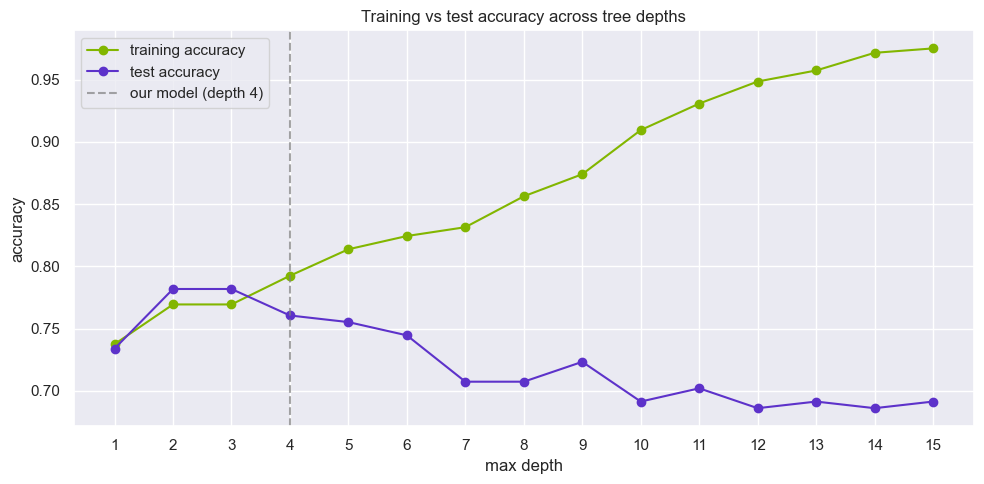

In [49]:
depths = list(range(1, 16))
train_acc, test_acc = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, color=GREEN,  marker="o", label="training accuracy")
plt.plot(depths, test_acc,  color=PURPLE, marker="o", label="test accuracy")
plt.axvline(x=4, color="gray", linestyle="--", alpha=0.7, label="our model (depth 4)")
plt.xlabel("max depth")
plt.ylabel("accuracy")
plt.title("Training vs test accuracy across tree depths")
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()

## A Regression Tree: Predicting Medical Charges

Same idea, but now the target is a number, not a class. I use an insurance dataset of 1,338 people with their age, BMI, smoking status, and the **medical charges** they were billed. Each leaf of a regression tree predicts the *average* charge of the people who land in it.

In [5]:
_local_insurance = os.path.join(os.getcwd(), "..", "Datasets", "insurance.csv")
try:
    ins = pd.read_csv(_local_insurance)
    print("loaded insurance data from local Datasets folder")
except FileNotFoundError:
    ins = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
    print("loaded insurance data from URL (local file not found)")

ins.head()

loaded insurance data from local Datasets folder


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Single-Feature Model

To see the staircase clearly, I fit a tree on a single feature, **age**, predicting charges. A shallow tree (depth 2) gives a few wide steps; a deeper one (depth 5) gives more, finer steps. The prediction is flat within each step, that's the "piecewise constant" nature of a tree. The vertical spread in the points is mostly from smoking, which this one-feature tree can't see yet.

Note: there's no train/test split here, this plot is purely a visual to show the staircase shape, not to evaluate performance. The proper evaluation with a split happens in the full feature model below.

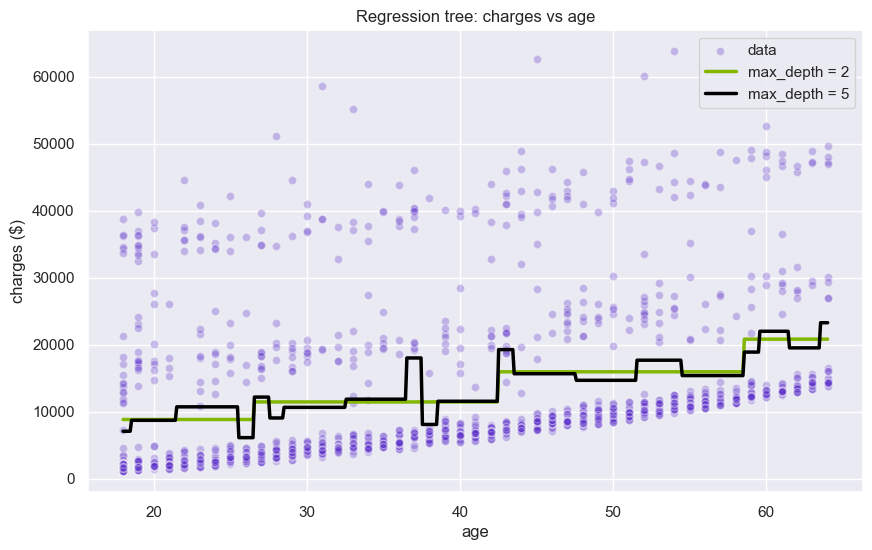

In [52]:
age = ins["age"].to_numpy().reshape(-1, 1)
charges = ins["charges"].to_numpy()
grid = np.linspace(age.min(), age.max(), 500).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(age, charges, color=PURPLE, alpha=0.3, edgecolors="white", label="data")
for depth, color in [(2, GREEN), (5, "black")]:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(age, charges)
    plt.plot(grid, reg.predict(grid), color=color, lw=2.5, label=f"max_depth = {depth}")
plt.xlabel("age"); plt.ylabel("charges ($)"); plt.title("Regression tree: charges vs age")
plt.legend()
plt.show()

### Full Feature Model

Using just age leaves out a lot. The full dataset has six input features, and we use all of them to predict `charges`:

| Column | Type | Description |
|---|---|---|
| `age` | numeric | patient's age in years |
| `bmi` | numeric | body mass index — a measure of body fat relative to height and weight |
| `children` | numeric | number of dependents covered under the insurance plan |
| `sex` | text → numeric | male or female; converted to a single 0/1 column called `sex_male` |
| `smoker` | text → numeric | yes or no; converted to a single 0/1 column called `smoker_yes` |
| `region` | text → numeric | one of four US regions (southwest, southeast, northwest, northeast); converted into 3 binary columns, one region is dropped because if you know the other three, you can infer the fourth (`drop_first=True`) |

The three text columns can't be fed directly into a tree, so `pd.get_dummies` converts them into 0/1 columns, this is called **one-hot encoding**. After encoding, `Xr` (the input matrix) has more columns than the original table, but carries the same information. `yr` is just `charges`, the value being predicted.

`smoker` turns out to be by far the most important feature because smokers are billed a lot more on average, and the tree learns to split on that first.

I compare the test error at three depths to show the overfitting tradeoff. **MAE (mean absolute error)** is the average dollar amount the tree is off by per patient, lower is better.

In [53]:
# Turn text columns (sex, smoker, region) into numeric 0/1 columns.
data = pd.get_dummies(ins, columns=["sex", "smoker", "region"], drop_first=True)
Xr = data.drop("charges", axis=1).to_numpy()
yr = data["charges"].to_numpy()
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

for depth in [3, 5, 20, 50]:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(Xr_train, yr_train)
    mae = mean_absolute_error(yr_test, reg.predict(Xr_test))
    print(f"max_depth={depth:2d}  test MAE: ${mae:,.0f}")

max_depth= 3  test MAE: $2,986
max_depth= 5  test MAE: $2,753
max_depth=20  test MAE: $2,687
max_depth=50  test MAE: $2,693


As depth increases, MAE drops, the tree makes finer splits and gets closer to each patient's actual charge. But this only goes so far. At a certain point the improvements shrink to almost nothing, and if you push depth high enough the tree starts memorizing training noise, so test MAE can plateau or even creep back up. The jump from depth 3 to 5 gives a meaningful improvement, but depth 20 to 50 barely moves the needle actually making it worse, a sign we're approaching that overfitting threshold.

Just like the classification tree, we can draw the full regression tree and read it top to bottom. Each box shows the split rule, the MSE of that node (how spread out the charges are), and the predicted value, the average charge of all training patients that land there.

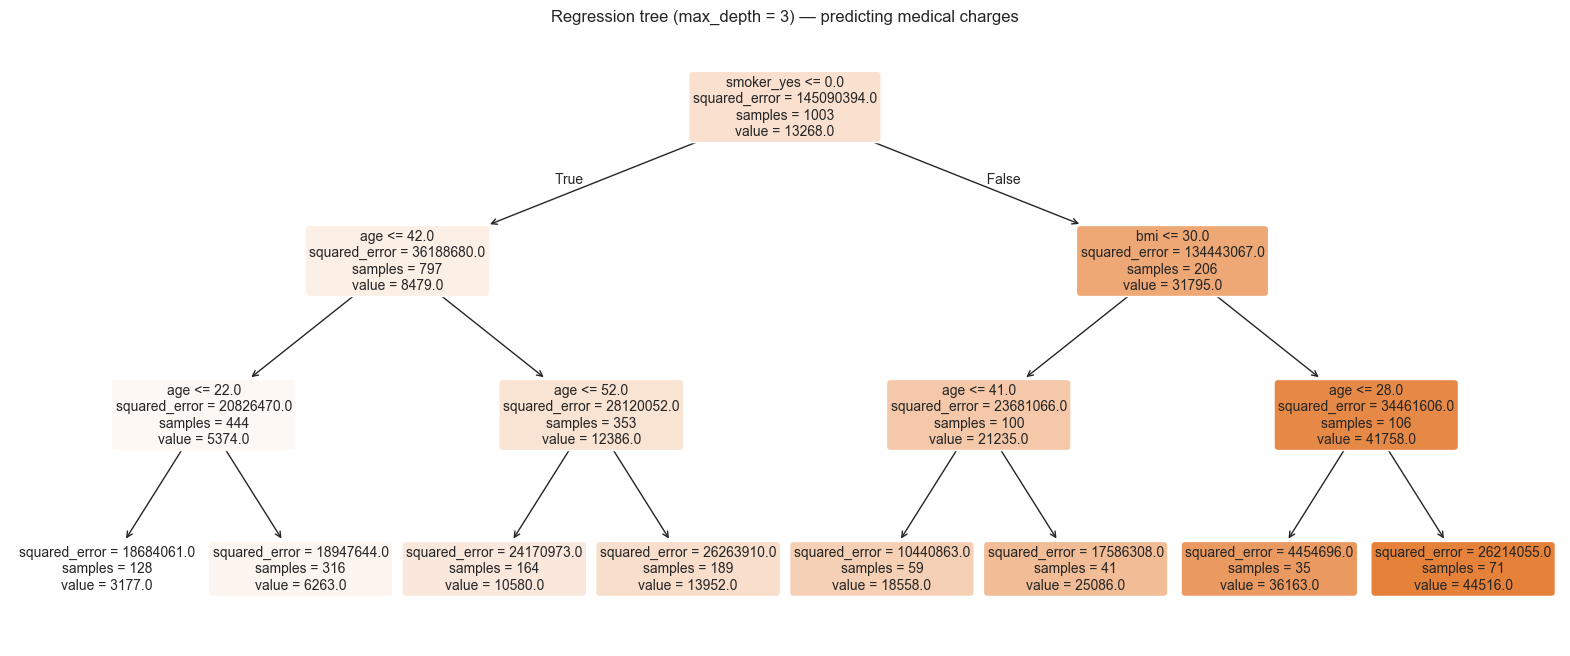

In [54]:
feature_names = list(pd.get_dummies(ins, columns=["sex", "smoker", "region"], drop_first=True).drop("charges", axis=1).columns)

reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42).fit(Xr_train, yr_train)

plt.figure(figsize=(20, 8))
plot_tree(reg_tree, feature_names=feature_names, filled=True, rounded=True,
          fontsize=10, precision=0)
plt.title("Regression tree (max_depth = 3) — predicting medical charges")
plt.show()

## Conclusion

A decision tree splits the feature space into rectangular blocks with simple yes/no rules, and a regression tree does the same but predicts the average value in each block, giving a staircase. The huge upside is that you can read a trained tree and understand exactly why it made a prediction. The downside, which showed up in both halves, is that trees overfit quickly once they get deep, carving the space into tiny islands that just memorize the training data.

That overfitting is the whole reason for the next notebook in this repository, on **ensemble methods**, which combine many trees into one stronger model. A **random forest** trains a bunch of trees on random slices of the data and averages them to smooth out the memorization, and **boosting** builds trees one after another, each one fixing the mistakes of the last. Both fix the single tree's biggest weakness while keeping its flexibility, and they're usually a big step up in accuracy.